Modelo: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Acurácia: 0.65
Precisão: 0.65
Recall: 0.65
f1 Score: 0.65


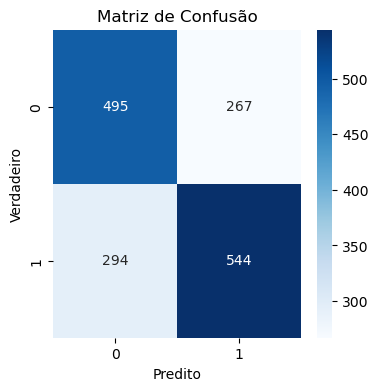

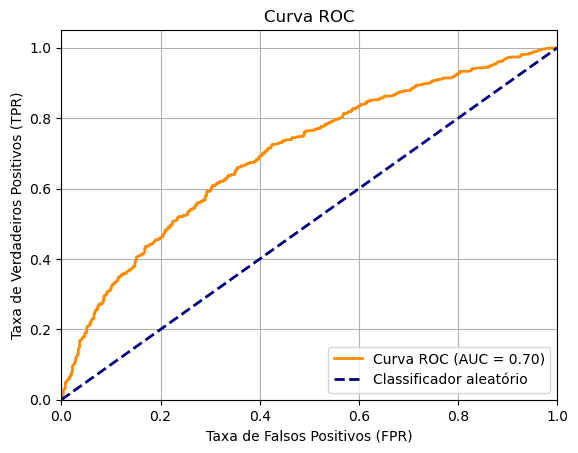

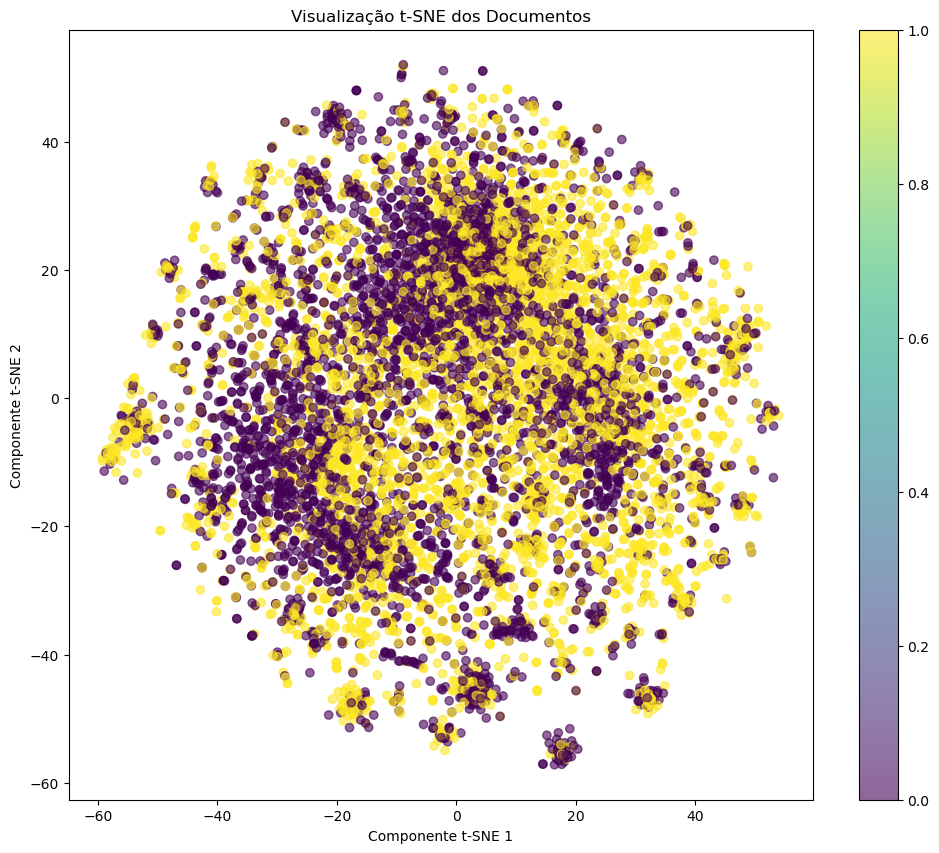

<Figure size 640x480 with 0 Axes>

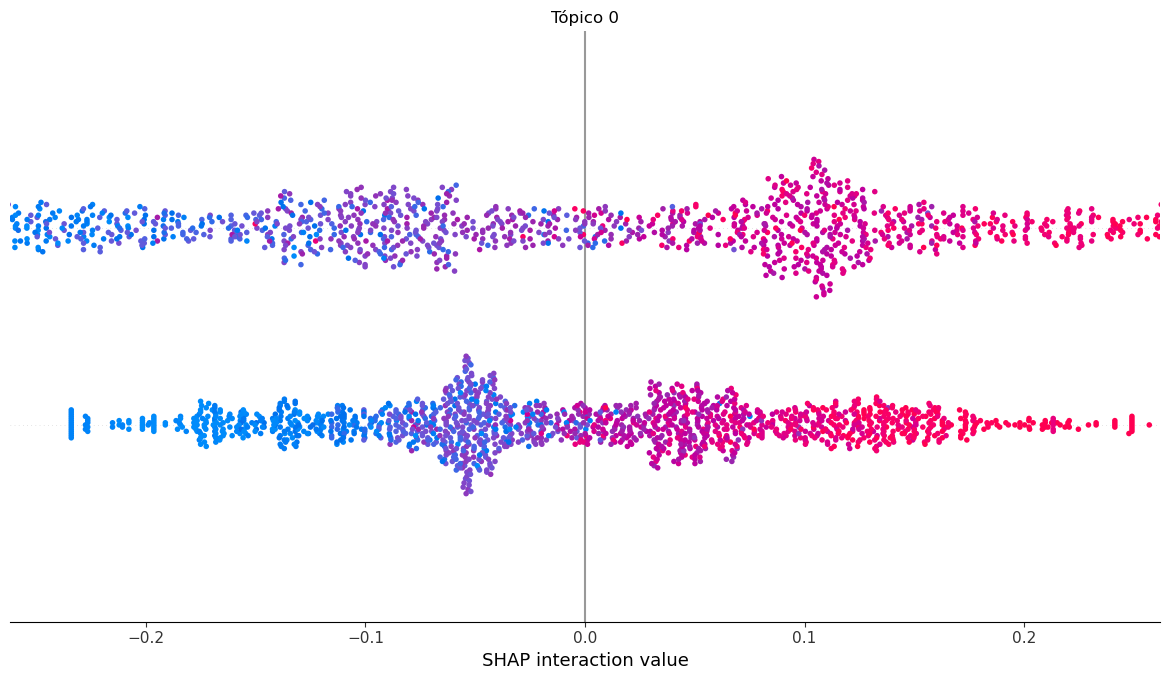

c:\Users\josem\miniconda3\Lib\site-packages\shap\plots\_force_matplotlib.py:107: RuntimeWarning: divide by zero encountered in scalar divide
  feature_contribution = np.abs(float(feature[0]) - pre_val) / np.abs(total_effect)


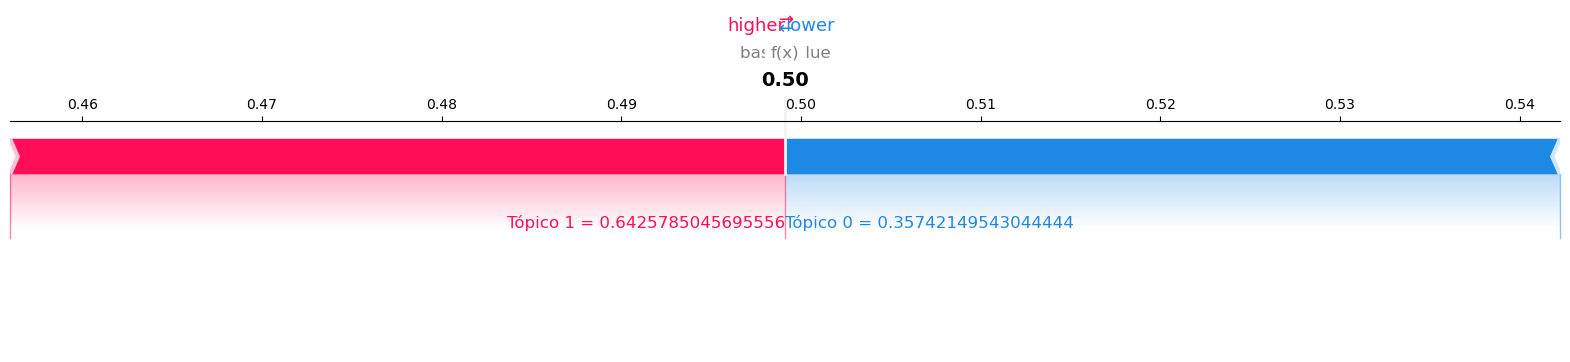

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.manifold import TSNE
from lime.lime_text import LimeTextExplainer
import shap as shap


def lemmatizer(text):
    lemmatizador = WordNetLemmatizer()
    tokens = word_tokenize(text)
    lemas = [lemmatizador.lemmatize(token) for token in tokens]
    return " ".join(lemas)

df = pd.read_csv("IMDB Dataset.csv").sample(8000)
textos = [lemmatizer(texto) for texto in df['review']]
target = df['sentiment'].apply(lambda target: 1 if target == 'positive' else 0)


vetorizador = TfidfVectorizer(max_features=500,stop_words='english', min_df=10, max_df=0.85)
vetor_textos = vetorizador.fit_transform(textos)
features = vetorizador.get_feature_names_out()
vetor_textos = pd.DataFrame(vetor_textos.toarray(), columns=features)

topicos = list(range(2,10))
modelos_lda = []
for num_topics in topicos:
        lda = LatentDirichletAllocation(
                n_components=num_topics,
                random_state=7,
                learning_method='online',
                max_iter=10)
        dist_topicos = lda.fit_transform(vetor_textos, target)
        lda_topicos = []
        for idx,topic in enumerate(lda.components_):
                lda_topicos.append(' '.join([features[i] for i in topic.argsort()[:-11:-1]]))
        modelos_lda.append({'modelo': lda, 'perplexity': lda.perplexity(dist_topicos),'dist_topicos': dist_topicos, 'topicos': lda_topicos})

best_lda = pd.DataFrame(modelos_lda).sort_values(by=['perplexity'])
best_lda = best_lda.iloc[0]

X_treino, X_teste, y_treino, y_teste = train_test_split(best_lda['dist_topicos'], target, test_size=0.20, random_state=7)

gridRF = GridSearchCV(RandomForestClassifier(random_state=7), 
             param_grid= {
                'n_estimators': [100, 200],
                'max_depth': [10, 20, None],
                'min_samples_split': [2, 5]
            }, cv=5, scoring='f1')
gridRF.fit(X_treino,y_treino)
y_pred = gridRF.best_estimator_.predict(X_teste)
y_proba = gridRF.best_estimator_.predict_proba(X_teste)
    
resultado = {
    'accuracy': accuracy_score(y_teste, y_pred),
    'f1_score': f1_score(y_teste, y_pred, average='weighted'),
    'precision': precision_score(y_teste, y_pred, average='weighted'),
    'recall': recall_score(y_teste, y_pred, average='weighted'),
    'cm': confusion_matrix(y_teste, y_pred),
    'modelo': gridRF.best_estimator_,
    'params': gridRF.best_estimator_.get_params(),
    'proba': y_proba
}

print(f"Modelo: {gridRF.best_params_}")
print(f"Acurácia: {resultado['accuracy']:.2f}")
print(f'Precisão: {resultado['precision']:.2f}')
print(f'Recall: {resultado['recall']:.2f}')
print(f'f1 Score: {resultado['f1_score']:.2f}')

plt.figure(figsize=(4,4))
sns.heatmap(resultado['cm'], annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusão')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

fpr, tpr, thresholds = roc_curve(y_teste, resultado['proba'][:, 1])
roc_auc = auc(fpr, tpr) # Calculando a área sob a curva

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Classificador aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

tsne = TSNE(n_components=2, random_state=7)
X_tsne = tsne.fit_transform(vetor_textos)

# Visualizar
plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=target, cmap='viridis', alpha=0.6)
plt.colorbar(scatter)
plt.title('Visualização t-SNE dos Documentos')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.show()

explainer = shap.TreeExplainer(resultado['modelo'])
shap_values = explainer.shap_values(X_teste)

# Summary plot
plt.title('Importância dos Tópicos (SHAP)')
shap.summary_plot(shap_values, X_teste, feature_names=[f"Tópico {i}" for i in range(len(best_lda['topicos']))   ])
plt.show()

# Force plot para uma instância específica
instance_idx = 0
shap.force_plot(explainer.expected_value[1], shap_values[1][instance_idx], X_teste[instance_idx], 
                feature_names=[f"Tópico {i}" for i in range(len(best_lda['topicos']))], matplotlib=True)
plt.show()

# Interpretação com LIME
def predict_proba_texts(textos):
    vetorizador = TfidfVectorizer(max_features=500,stop_words='english', min_df=10, max_df=0.85)
    textos_tfidf = vetorizador.fit_transform(textos)
    textos_tfidf = pd.DataFrame(textos_tfidf, columns=vetorizador.get_feature_names_out())
    dist_topicos = best_lda.transform(textos_tfidf)
    return resultado['modelo'].predict_proba(dist_topicos)

# explainer = LimeTextExplainer(class_names=['Positivo', 'Negativo'])
# idx = 0
# exp = explainer.explain_instance(X_teste[idx], resultado['modelo'].predict_proba, num_features=5)
# print(f"Explicação LIME para review: {X_teste[idx]}...")
# print(f"Previsão real: {'Positivo' if y_teste[idx] == 1 else 'Negativo'}")
# exp.show_in_notebook()


# Conclusão
# a. O resultado das métricas do modelo de previsão mostrou um modelo semi-ineficaz para a identificação do target pelos topicos,
#  apesar de ter conseguido prever corretamente 2/3 dos valores mas não foi possível separar de forma eficaz.

# b. Já o T-SNE mostrou que não há uma divisão clara do vetor TF IDF em relação aos targets do dataset.

# c. Já o SHAP indica que apesar de uma aparente separação,
#  tem se ainda uma mistura de pontos muito grande que explica o baixo dicernimento do modelo da análise